In [1]:
!pip install scikit-fda


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 5.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skfda import FDataGrid

from skfda.preprocessing.dim_reduction import FPCA

# 1. Загрузка погодных данных
from skfda.datasets import fetch_weather

X, y = fetch_weather(return_X_y=True, as_frame=True)
fd = X.iloc[:, 0].array
target = y.array
fd_temperatures = fd.coordinates[0]


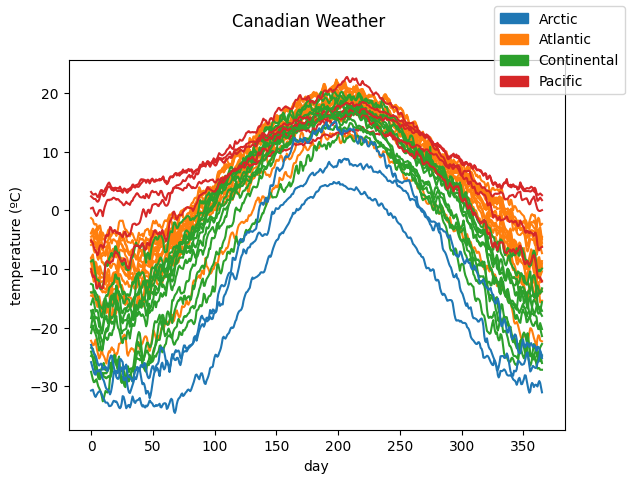

In [3]:
import matplotlib.pyplot as plt

label_names = target.categories

fd_temperatures.plot(
    group=target.codes,
    group_names=label_names,
)
plt.show()


In [26]:
import skfda

n_basis = 5

# basis = skfda.representation.basis.MonomialBasis(
#     domain_range=(0,365), n_basis=n_basis
# )

basis = skfda.representation.basis.FourierBasis(
    domain_range=(0, 365), n_basis=n_basis, period=None)


basis_fd = fd_temperatures.to_basis(basis)
fpca_basis = FPCA(n_basis)
fpca = fpca_basis.fit(basis_fd)

# The sign of the components is arbitrary, but this way it is easier to
# understand.
fpca.components_ *= -1


посмотреть всем sindy!!


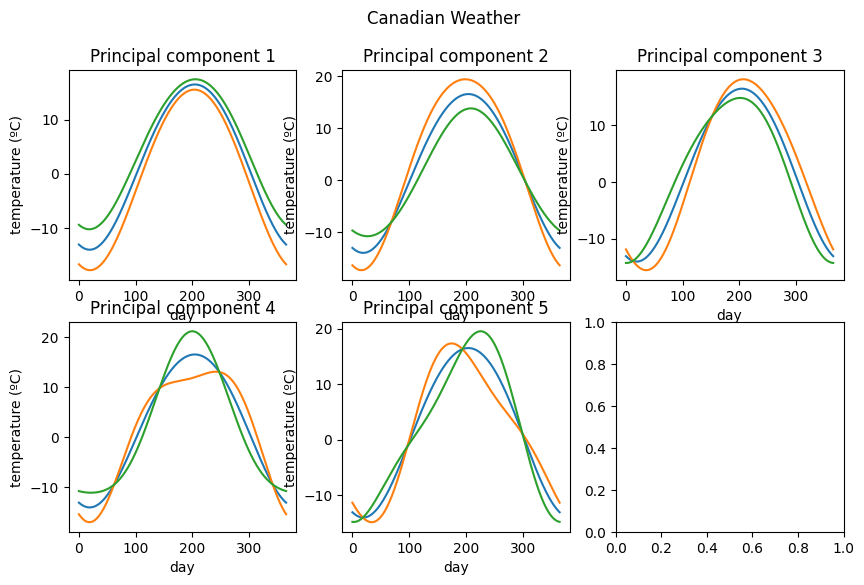

In [28]:
from skfda.exploratory.visualization.fpca import FPCAPlot

fig = plt.figure(figsize=(10, 6))
FPCAPlot(
    fpca.mean_,
    fpca.components_,
    factor=50,
    fig=fig,
).plot()
plt.show()

COMPONENT: 0


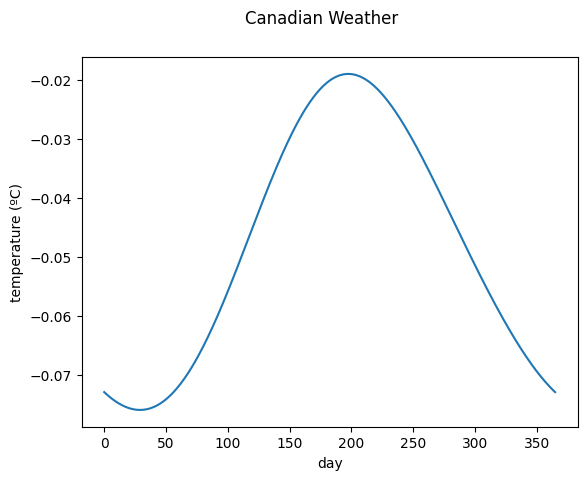

In [29]:
i = 0
print(f"COMPONENT: {i}")
_ = FPCAPlot(
    fpca.mean_,
    fpca.components_,
    factor=50,
    fig=fig,
).components[i].plot()

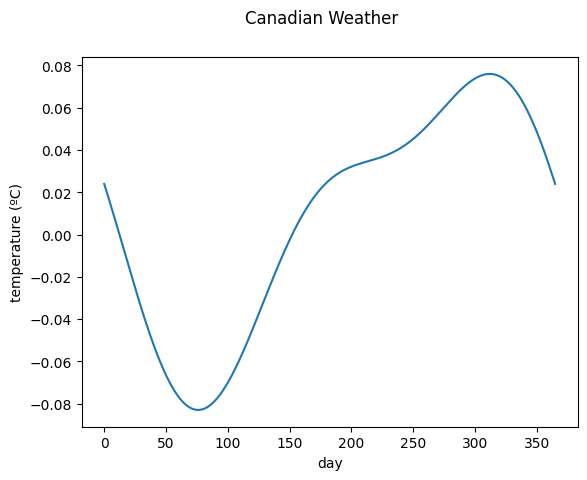

In [30]:
_ = FPCAPlot(
    fpca.mean_,
    fpca.components_,
    factor=50,
    fig=fig,
).components[2].plot()

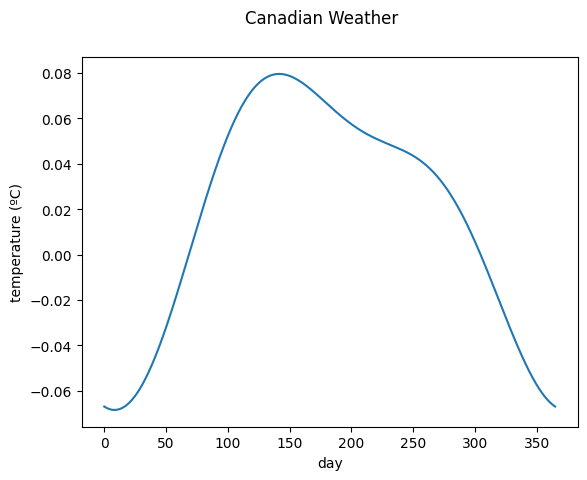

In [31]:
_ = FPCAPlot(
    fpca.mean_,
    fpca.components_,
    factor=50,
    fig=fig,
).components[1].plot()

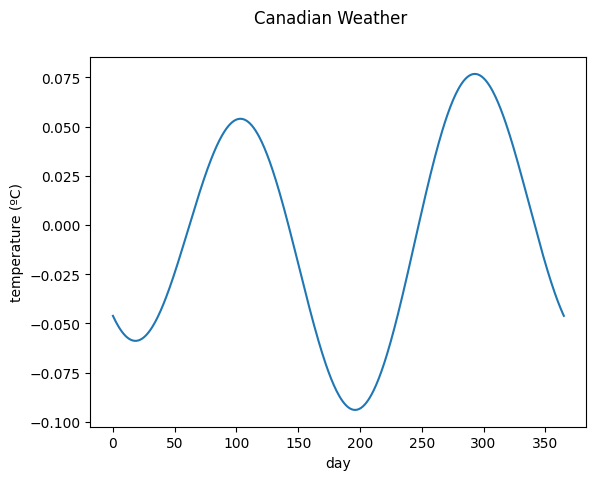

In [32]:
_ = FPCAPlot(
    fpca.mean_,
    fpca.components_,
    factor=50,
    fig=fig,
).components[3].plot()